# 5.1 Google Trends: Descriptive Analysis

This notebook performs descriptive analysis on the stitched daily Google Trends data.

**Input:** `Data/1_Bronze/Google Trends/Storage/trends_daily_stitched.csv`  


<!-- toc -->
## Contents
- [1. Load & inspect](#1-load-inspect)
- [2. All keywords over time](#2-all-keywords-over-time)
- [3. Candidate comparison with key event annotations](#3-candidate-comparison-with-key-event-annotations)
- [4. Trump–Harris search gap (daily difference)](#4-trumpharris-search-gap-daily-difference)
- [5. Smoothed trends 7-day rolling average](#5-smoothed-trends-7-day-rolling-average)
- [6. Interest by US state top states per candidate](#6-interest-by-us-state-top-states-per-candidate)
- [7. Rising related queries Trump vs Harris](#7-rising-related-queries-trump-vs-harris)
- [8. Correlation with Polymarket odds](#8-correlation-with-polymarket-odds)
- [Summary](#summary)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
sys.path.insert(0, '../..')
from house_style import (
    REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT, TEXT_PRIMARY, TEXT_MUTED,
    BG_DARK, BG_PANEL, GRID_COLOR, SPINE_COLOR, EVENTS,
    apply_style, style_ax, styled_fig, add_events, event_legend_handles
    C_VIX,
    C_SP500,
    C_FEAR,
    C_ANGER,
    C_TRUST,
    C_DISGUST,
    C_SADNESS,
    C_JOY,
    C_ANTICIPATION,
)
apply_style()

BRONZE_PATH = '../../Data/1_Bronze/Google_Trends/'

KEYWORDS = [
    'trump', 'kamala', 'biden', 'elon musk',
    'election 2024', 'vote', 'conspiracy',
    'walz', 'vance', 'campaign',
]

COLOR_MAP = {
    'trump'         : REPUBLICAN,
    'kamala'        : DEMOCRAT,
    'biden'         : '#5a9fd4',
    'elon musk'     : '#f0a500',
    'election 2024' : NEUTRAL,
    'vote'          : '#2ec4b6',
    'conspiracy'    : '#9b5de5',
    'walz'          : '#4fc3f7',
    'vance'         : '#ef5350',
    'campaign'      : '#aaaaaa',
}

print('Libraries loaded, house style applied.')

Libraries loaded, house style applied.


## 1. Load & inspect

In [2]:
df = pd.read_csv(f'{BRONZE_PATH}trends_daily_stitched.csv', index_col='date', parse_dates=True)

print(f'Shape       : {df.shape}')
print(f'Date range  : {df.index.min().date()} → {df.index.max().date()}')
print(f'Missing days: {(df.index.to_series().diff().dt.days > 1).sum()}')
print(f'\nMissing values per keyword:')
print(df.isna().sum())
print(f'\nBasic statistics:')
df.describe().round(1)

Shape       : (123, 10)
Date range  : 2024-07-05 → 2024-11-04
Missing days: 0

Missing values per keyword:
trump            0
kamala           0
biden            0
elon musk        0
election 2024    0
vote             0
conspiracy       0
walz             0
vance            0
campaign         0
dtype: int64

Basic statistics:


,trump,kamala,biden,elon musk,election 2024,vote,conspiracy,walz,vance,campaign
count,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0
mean,7.5,2.7,1.8,0.2,0.1,1.9,0.0,0.6,1.1,0.1
std,10.8,2.5,4.1,0.3,0.2,4.1,0.0,1.7,2.4,0.2
min,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,4.0,1.5,0.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0
50%,5.0,2.0,1.0,0.0,0.0,1.0,0.0,0.2,0.3,0.0
75%,7.0,3.0,1.0,0.1,0.0,1.5,0.0,0.7,1.0,0.0
max,100.0,15.0,39.0,2.0,1.0,36.7,0.0,15.0,22.0,1.0


## 2. All keywords over time

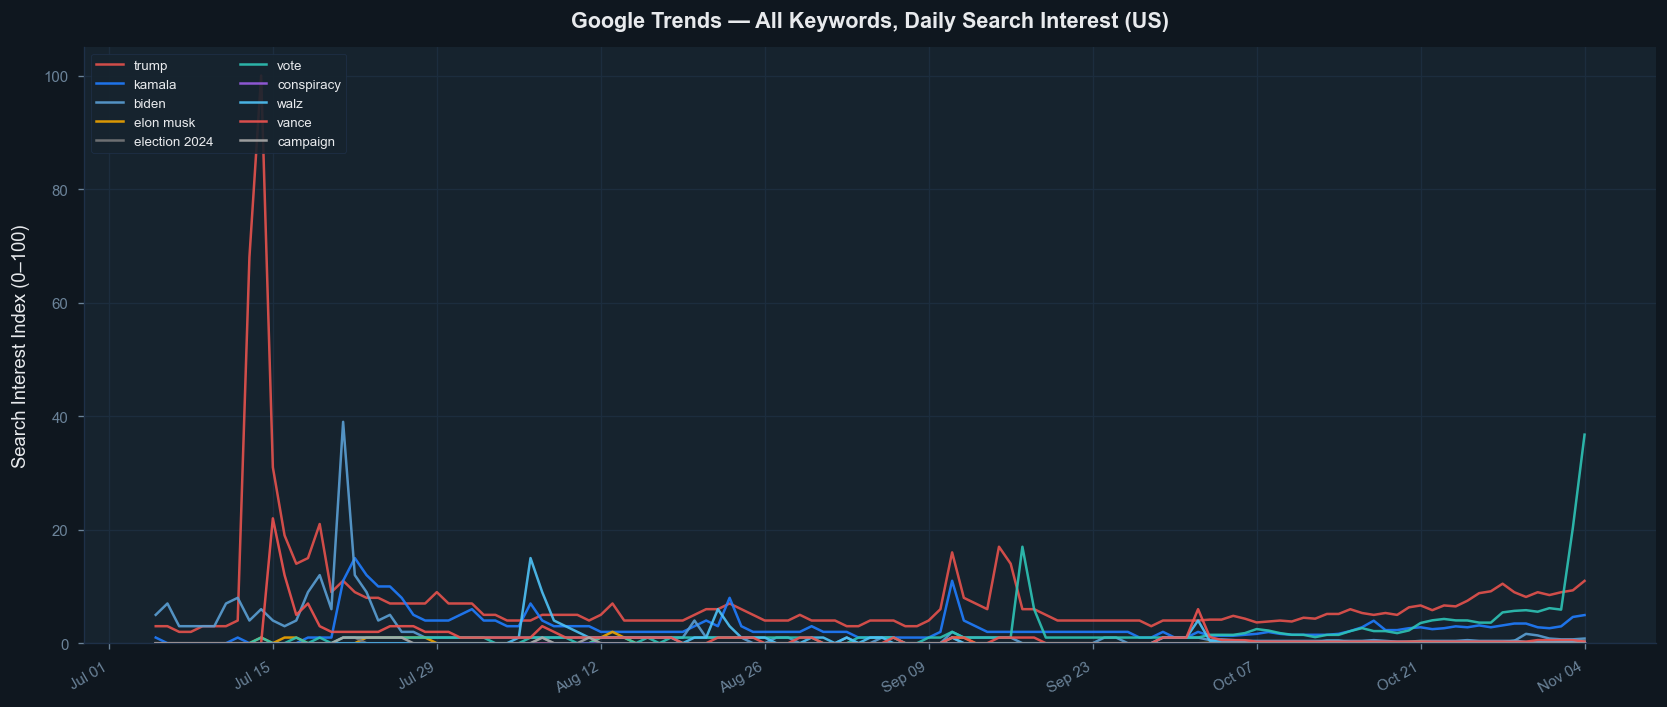

In [3]:
fig, ax = styled_fig(figsize=(14, 6))

for kw in KEYWORDS:
    ax.plot(df.index, df[kw], label=kw, color=COLOR_MAP[kw], linewidth=1.5, alpha=0.9)

style_ax(ax, title='Google Trends — All Keywords, Daily Search Interest (US)',
         ylabel='Search Interest Index (0–100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_all_keywords.png')
plt.show()

## 3. Candidate comparison with key event annotations

Annotating major events helps interpret spikes and drops in search interest.

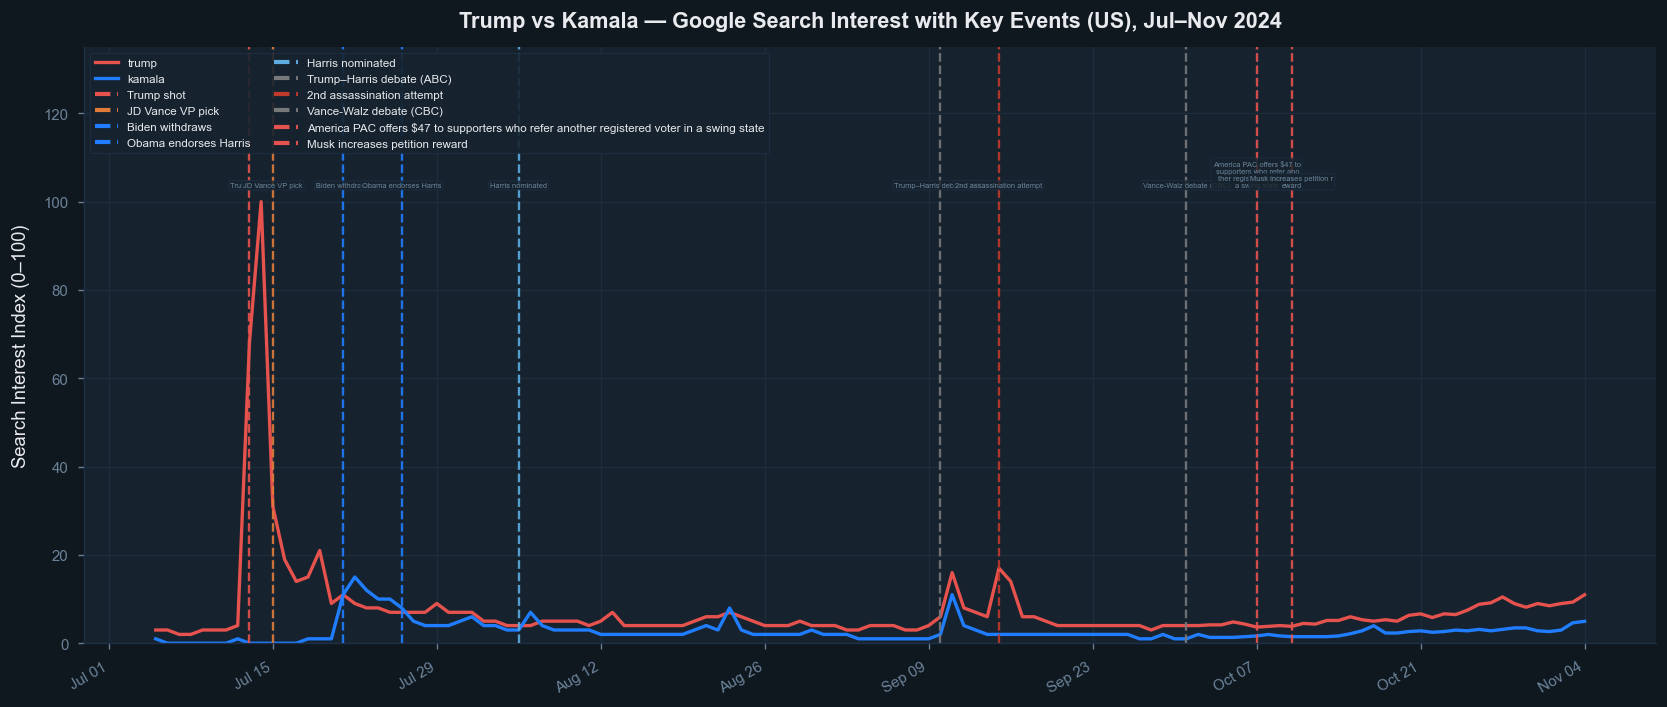

10 events defined in house_style, 10 within plot range


In [4]:
import pandas as pd

fig, ax = styled_fig(figsize=(14, 6))

ax.plot(df.index, df['trump'],  label='trump',  color=REPUBLICAN, linewidth=2)
ax.plot(df.index, df['kamala'], label='kamala', color=DEMOCRAT,   linewidth=2)

# Draw event lines using house_style EVENTS
add_events(ax)

# Annotate each event label at top of plot
for lbl, date_str, color in EVENTS:
    d = pd.Timestamp(date_str)
    if df.index.min() <= d <= df.index.max():
        short_lbl = '\n'.join([lbl[i:i+25] for i in range(0, len(lbl), 25)])
        ax.text(d, 103, short_lbl, fontsize=4.5, color=TEXT_MUTED,
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=BG_PANEL,
                          edgecolor=SPINE_COLOR, alpha=0.8))

style_ax(ax,
         title='Trump vs Kamala — Google Search Interest with Key Events (US), Jul–Nov 2024',
         ylabel='Search Interest Index (0–100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')

# Candidate lines legend + event legend
candidate_handles, candidate_labels = ax.get_legend_handles_labels()
event_handles = event_legend_handles()
ax.legend(candidate_handles + event_handles,
          candidate_labels + [h.get_label() for h in event_handles],
          loc='upper left', fontsize=7, ncol=2)
ax.set_ylim(0, 135)

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_candidates_annotated.png')
plt.show()

print(f'{len(EVENTS)} events defined in house_style, '
      f'{sum(df.index.min() <= pd.Timestamp(d) <= df.index.max() for _, d, _ in EVENTS)} within plot range')

## 4. Trump–Harris search gap (daily difference)

Positive values = Trump searched more than Harris on that day.

Trump leads in search: 93.5% of days
Kamala leads in search: 6.5% of days
Mean gap: 4.8


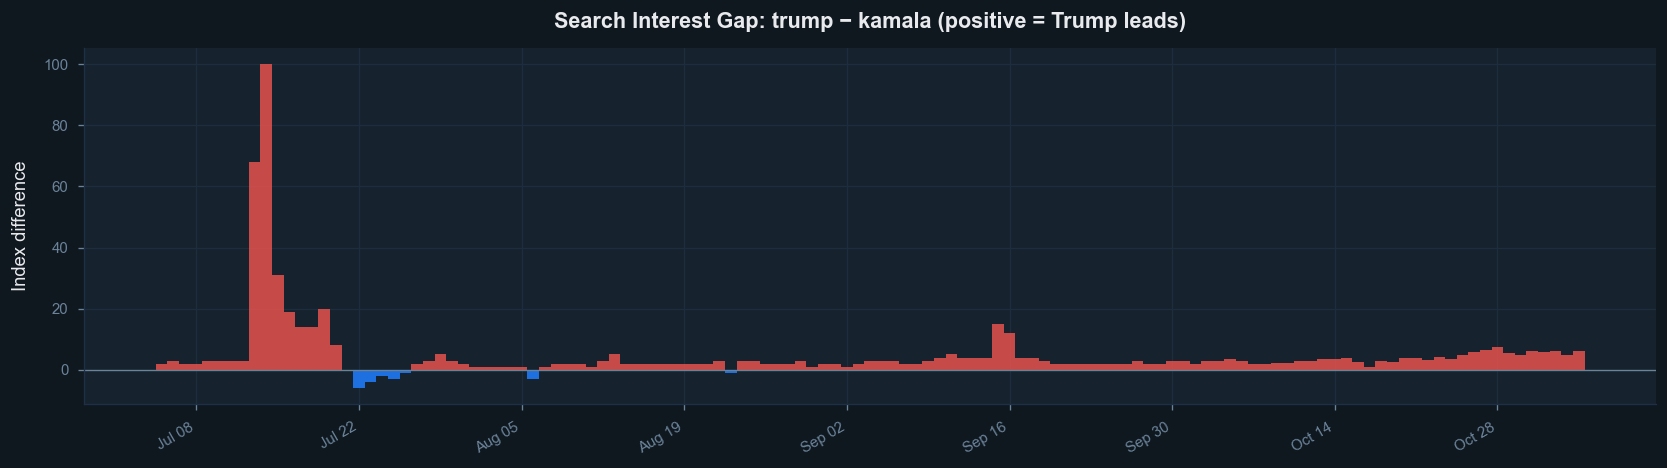

In [5]:
gap = df['trump'] - df['kamala']

fig, ax = styled_fig(figsize=(14, 4))

ax.bar(df.index, gap,
       color=[REPUBLICAN if v >= 0 else DEMOCRAT for v in gap],
       width=1, alpha=0.85)
ax.axhline(0, color=TEXT_MUTED, linewidth=0.8)

style_ax(ax,
         title='Search Interest Gap: trump − kamala (positive = Trump leads)',
         ylabel='Index difference')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')

pct_trump_leads = (gap > 0).mean() * 100
print(f'Trump leads in search: {pct_trump_leads:.1f}% of days')
print(f'Kamala leads in search: {100-pct_trump_leads:.1f}% of days')
print(f'Mean gap: {gap.mean():.1f}')

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_search_gap.png')
plt.show()

## 5. Smoothed trends 7-day rolling average

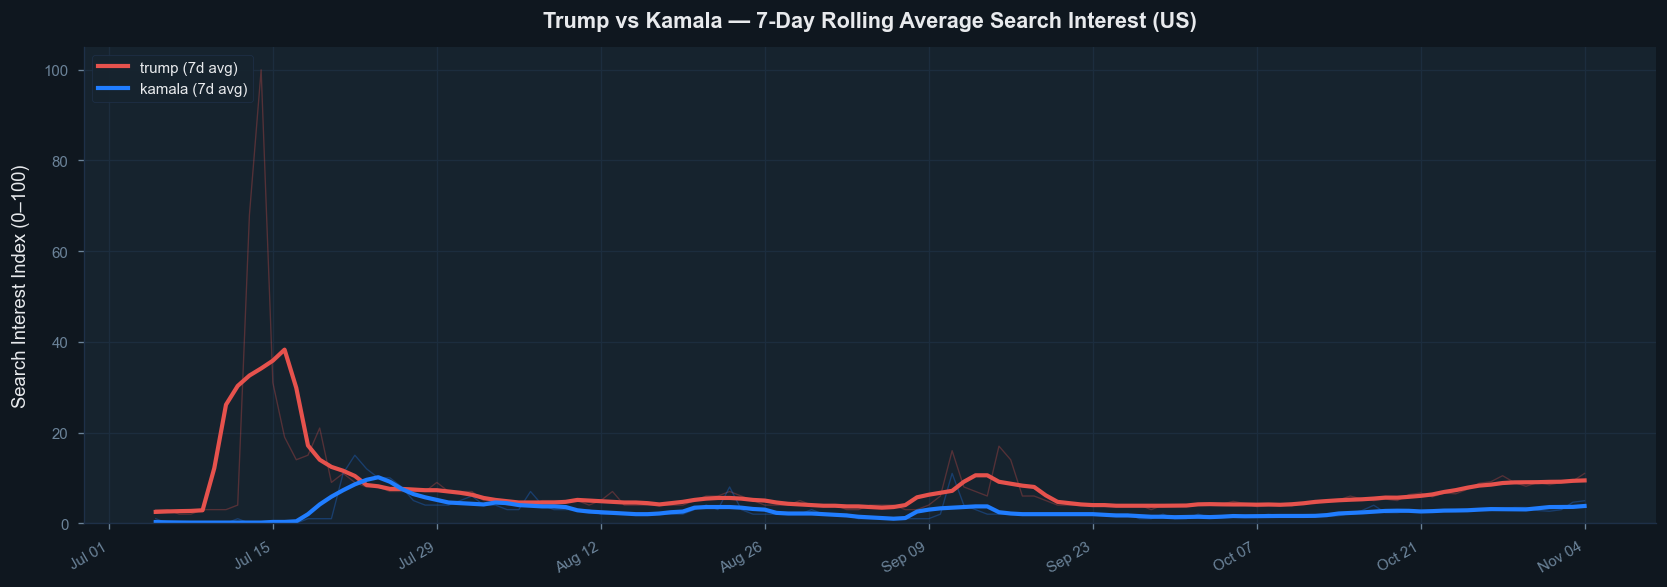

In [6]:
df_roll = df[['trump', 'kamala']].rolling(7, min_periods=4, center=True).mean()

fig, ax = styled_fig(figsize=(14, 5))

# Raw (faded)
ax.plot(df.index, df['trump'],  color=REPUBLICAN, linewidth=0.8, alpha=0.3)
ax.plot(df.index, df['kamala'], color=DEMOCRAT,   linewidth=0.8, alpha=0.3)

# Smoothed
ax.plot(df_roll.index, df_roll['trump'],  label='trump (7d avg)',  color=REPUBLICAN, linewidth=2.5)
ax.plot(df_roll.index, df_roll['kamala'], label='kamala (7d avg)', color=DEMOCRAT,   linewidth=2.5)

style_ax(ax,
         title='Trump vs Kamala — 7-Day Rolling Average Search Interest (US)',
         ylabel='Search Interest Index (0–100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')
ax.legend(loc='upper left')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_rolling_avg.png')
plt.show()

## 6. Interest by US state top states per candidate

In [7]:
df_states = pd.read_csv(f'{BRONZE_PATH}trends_by_state.csv', index_col=0)
print(f'States data shape: {df_states.shape}')
df_states.head()

States data shape: (51, 10)


,trump,kamala,biden,elon musk,election 2024,vote,conspiracy,walz,vance,campaign
geoName,,,,,,,,,,
Alabama,58,21,15,3,3,14.939394,0.00000,4.393939,10.545455,2.416667
Alaska,58,20,14,3,5,12.608696,0.84058,5.043478,7.565217,3.052632
Arizona,56,23,14,3,4,16.369231,0.00000,6.030769,7.753846,2.947368
Arkansas,57,21,15,3,4,16.661538,0.00000,5.261538,8.769231,2.375000
California,56,23,14,4,3,12.352941,0.00000,5.764706,8.235294,2.947368


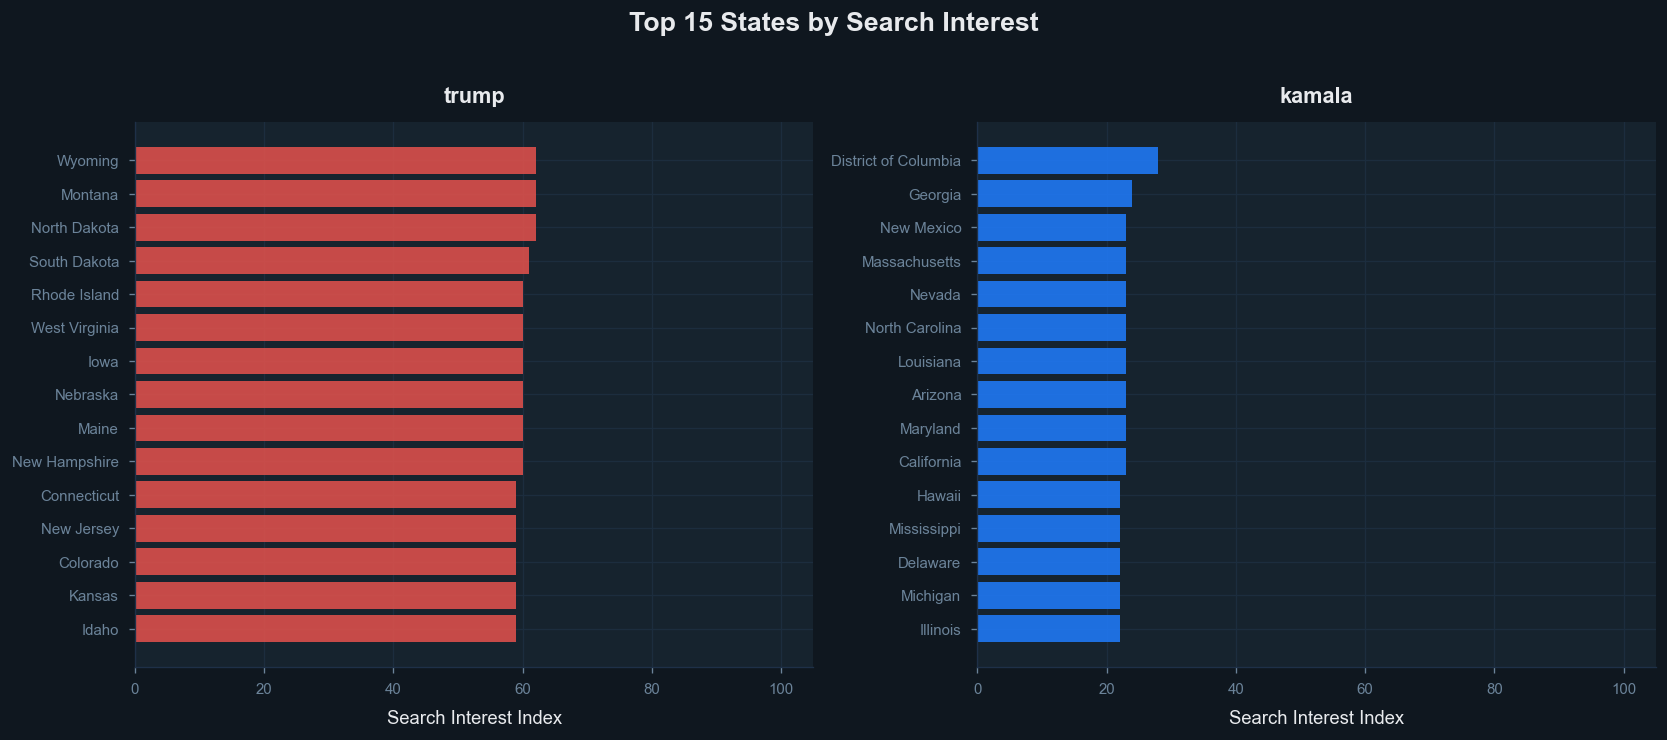

In [8]:
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(14, 6),
                       title='Top 15 States by Search Interest')

for ax, (candidate, color) in zip(axes, [('trump', REPUBLICAN), ('kamala', DEMOCRAT)]):
    if candidate not in df_states.columns:
        ax.text(0.5, 0.5, f'{candidate} not in data', transform=ax.transAxes,
                ha='center', color=TEXT_MUTED)
        continue
    top15 = df_states[candidate].nlargest(15).sort_values()
    ax.barh(top15.index, top15.values, color=color, alpha=0.85)
    style_ax(ax, title=candidate, xlabel='Search Interest Index', grid_axis='x')
    ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_states_top15.png')
plt.show()

## 7. Rising related queries Trump vs Harris

In [9]:
import os

for kw in KEYWORDS:
    safe_name = kw.replace(' ', '_').lower()
    path_rising = f'{BRONZE_PATH}related_queries_{safe_name}_rising.csv'
    if not os.path.exists(path_rising):
        print(f'File not found: {path_rising}')
        continue
    rising = pd.read_csv(path_rising).head(15)
    if rising.empty:
        print(f'No rising queries for {kw}')
        continue

    fig, ax = styled_fig(figsize=(10, 5))
    ax.barh(rising['query'], rising['value'], color=COLOR_MAP.get(kw, NEUTRAL), alpha=0.85)
    style_ax(ax, title=f'Top Rising Queries — "{kw}"',
             xlabel='Breakout value', grid_axis='x')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{BRONZE_PATH}plot_rising_queries_{safe_name}.png')
    plt.show()

File not found: ../../Data/1_Bronze/Google_Trends/related_queries_trump_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_kamala_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_biden_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_elon_musk_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_election_2024_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_vote_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_conspiracy_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_walz_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_vance_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_campaign_rising.csv


## 8. Correlation with Polymarket odds

Quick check: do Google search spikes correlate with movements in Polymarket odds?

In [10]:
POLY_PATH = '../../Data/1_Bronze/Polymarket/polymarket_win_probabilities.csv'

df_poly = pd.read_csv(POLY_PATH, parse_dates=['date']).set_index('date').sort_index()
df_poly.columns = ['trump_price', 'harris_price']

print(f'Polymarket shape : {df_poly.shape}')
print(f'Date range       : {df_poly.index.min().date()} → {df_poly.index.max().date()}')
df_poly.head()

Polymarket shape : (128, 2)
Date range       : 2024-07-01 → 2024-11-05


,trump_price,harris_price
date,,
2024-07-01,66.0,4.45
2024-07-02,65.0,9.65
2024-07-03,61.5,15.50
2024-07-04,60.5,20.10
2024-07-05,60.5,15.95


Merged shape: (123, 4)

Correlation matrix:
              trump  kamala  trump_price  harris_price
trump         1.000  -0.063        0.414        -0.461
kamala       -0.063   1.000        0.086         0.133
trump_price   0.414   0.086        1.000        -0.847
harris_price -0.461   0.133       -0.847         1.000


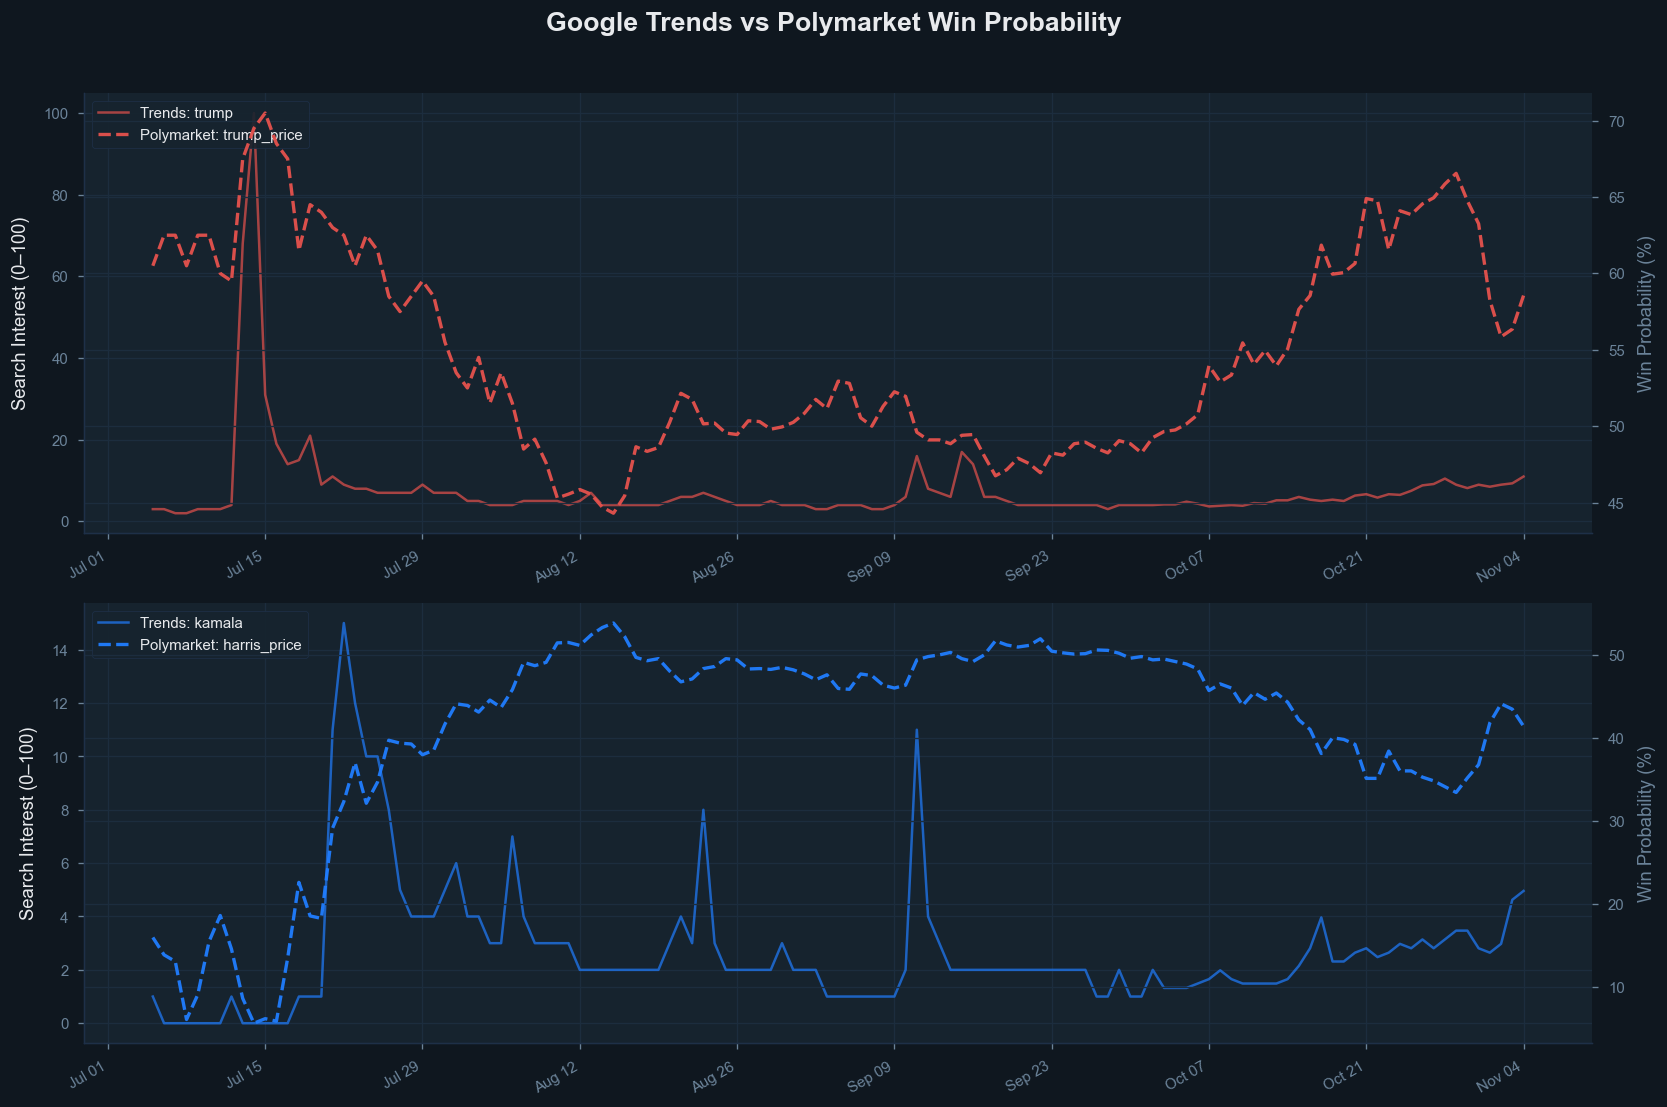

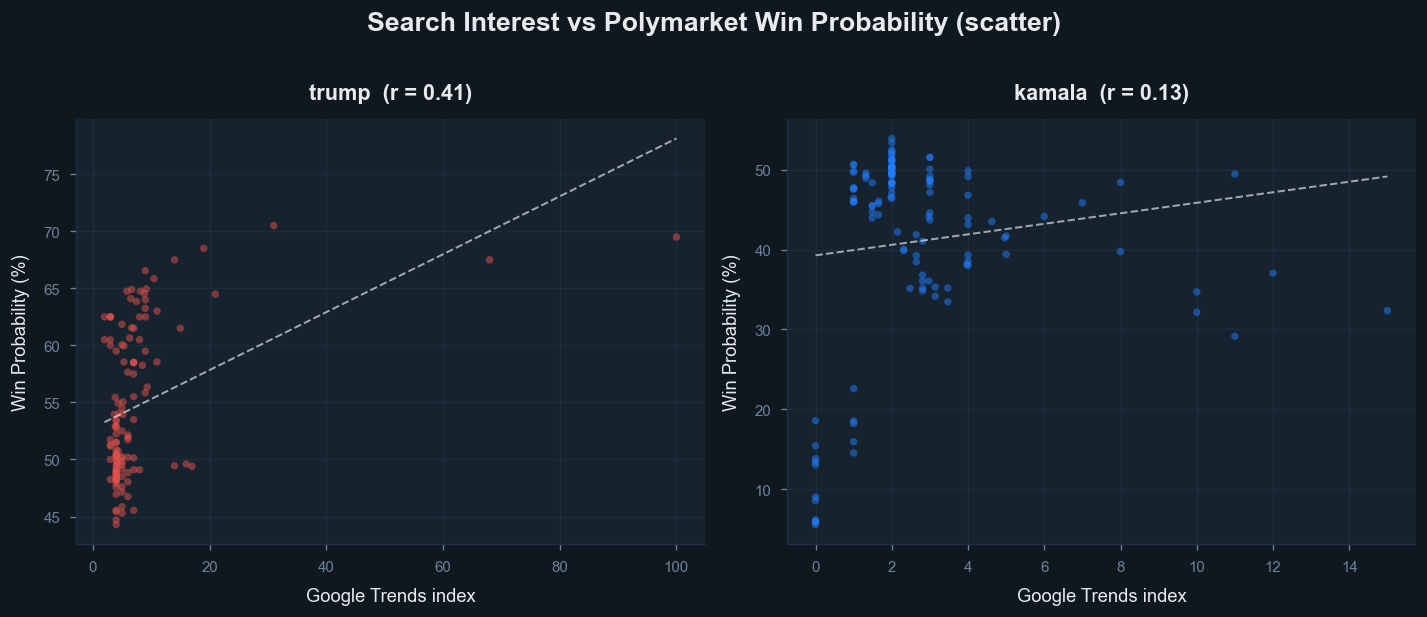

In [11]:
merged = df[['trump', 'kamala']].join(df_poly[['trump_price', 'harris_price']], how='inner')

print(f'Merged shape: {merged.shape}')
print(f'\nCorrelation matrix:')
print(merged.corr().round(3))

# ── Plot 1: Trends + Polymarket over time (dual axis) ────────────────────────
fig, axes = styled_fig(nrows=2, ncols=1, figsize=(14, 9),
                       title='Google Trends vs Polymarket Win Probability')

for ax, (search_kw, price_col, color) in zip(axes, [
    ('trump',  'trump_price',  REPUBLICAN),
    ('kamala', 'harris_price', DEMOCRAT),
]):
    ax2 = ax.twinx()

    ax.plot(merged.index, merged[search_kw], color=color, linewidth=1.5,
            alpha=0.7, label=f'Trends: {search_kw}')
    ax2.plot(merged.index, merged[price_col], color=color, linewidth=2,
             linestyle='--', alpha=0.95, label=f'Polymarket: {price_col}')

    style_ax(ax, ylabel='Search Interest (0–100)')
    ax2.set_ylabel('Win Probability (%)', color=TEXT_MUTED)
    ax2.tick_params(colors=TEXT_MUTED)
    ax2.set_facecolor(BG_PANEL)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_trends_vs_polymarket.png')
plt.show()

# ── Plot 2: Scatter — search interest vs win probability ────────────────────
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(12, 5),
                       title='Search Interest vs Polymarket Win Probability (scatter)')

for ax, (search_kw, price_col, color) in zip(axes, [
    ('trump',  'trump_price',  REPUBLICAN),
    ('kamala', 'harris_price', DEMOCRAT),
]):
    ax.scatter(merged[search_kw], merged[price_col],
               color=color, alpha=0.5, s=20, edgecolors='none')

    # Trend line
    z = np.polyfit(merged[search_kw].dropna(), merged[price_col].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged[search_kw].min(), merged[search_kw].max(), 100)
    ax.plot(x_line, p(x_line), color='white', linewidth=1.2, linestyle='--', alpha=0.6)

    corr = merged[[search_kw, price_col]].corr().iloc[0, 1]
    style_ax(ax,
             title=f'{search_kw}  (r = {corr:.2f})',
             xlabel='Google Trends index',
             ylabel='Win Probability (%)')

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_trends_polymarket_scatter.png')
plt.show()

## Summary

Key findings from the descriptive analysis:
- **Trump** — candidate that dominated search overall
- **Trump got shot** — events that caused the largest search spikes
- **Not necessarily very prominent correlation** — correlation direction between search interest and Polymarket odds

**Features to carry forward to the basetable:**
- `trends_trump` — daily search index for 'trump'
- `trends_kamala` — daily search index for 'kamala'
- `trends_election` — daily search index for 'election 2024'
- `trends_gap` — trump minus kamala daily difference
- `trends_trump_7d` — 7-day rolling average (trump)
- `trends_kamala_7d` — 7-day rolling average (kamala)